# Python for Data Analysis & Visualiion

Final Project

Team -1 

Team Member:


Balu Prakash Kunchala 

Sarita Bhatta 

Yesaswi Kolla


 Date:04/29/2024




In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ***Section 1: Dataset Exploration***

### 1. Loading the dataset into a Pandas dataframe and displaying the first 10 rows:

   

In [5]:
df = pd.read_excel("nba_stats.xlsx", sheet_name="STATS")
df.head(10)

,Player,Pos,Age,Tm,G,GS,MP,FG,FGA,FG%,...,FT,FTA,ORB,DRB,AST,STL,BLK,PF,PTS,YEAR
0,Kareem Abdul-Jabbar*,C,41,LAL,74,74,1695,313,659,0.475,...,122,165,103,231,74,38,85,196,748,88-89
1,Mark Acres,C,26,BOS,62,0,632,55,114,0.482,...,26,48,59,87,19,19,6,94,137,88-89
2,Michael Adams,PG,26,DEN,77,77,2787,468,1082,0.433,...,322,393,71,212,490,166,11,149,1424,88-89
3,Mark Aguirre,SF,29,TOT,80,76,2597,586,1270,0.461,...,288,393,146,240,278,45,36,229,1511,88-89
4,Mark Aguirre,SF,29,DAL,44,44,1529,373,829,0.450,...,178,244,90,145,189,29,29,128,953,88-89
5,Mark Aguirre,SF,29,DET,36,32,1068,213,441,0.483,...,110,149,56,95,89,16,7,101,558,88-89
6,Danny Ainge,PG,29,TOT,73,54,2377,480,1051,0.457,...,205,240,71,184,402,93,8,186,1281,88-89
7,Danny Ainge,PG,29,BOS,45,28,1349,271,589,0.460,...,114,128,37,117,215,52,1,108,714,88-89
8,Danny Ainge,PG,29,SAC,28,26,1028,209,462,0.452,...,91,112,34,67,187,41,7,78,567,88-89
9,Mark Alarie,PF,25,WSB,74,5,1141,206,431,0.478,...,73,87,103,152,63,25,22,160,498,88-89


### 2. Displaying the shape of the dataset (i.e. number of rows and columns):

In [6]:
Number_of_rows, Number_of_columns = df.shape
Number_of_rows, Number_of_columns


(5459, 26)

### 3.	Identifying the data types of each column and check for any missing values (number of missing values in each column): 

In [7]:
### Finding the data types for each column
df.dtypes



Player     object
Pos        object
Age         int64
Tm         object
G           int64
GS          int64
MP          int64
FG          int64
FGA         int64
FG%       float64
3P          int64
3PA         int64
3P%       float64
2P          int64
2PA         int64
2P%       float64
FT          int64
FTA         int64
ORB         int64
DRB         int64
AST         int64
STL         int64
BLK         int64
PF          int64
PTS         int64
YEAR       object
dtype: object

In [8]:

# Finding the missing values in each column
df.isna().sum()


Player      0
Pos         0
Age         0
Tm          0
G           0
GS          0
MP          0
FG          0
FGA         0
FG%        25
3P          0
3PA         0
3P%       997
2P          0
2PA         0
2P%        32
FT          0
FTA         0
ORB         0
DRB         0
AST         0
STL         0
BLK         0
PF          0
PTS         0
YEAR        0
dtype: int64

#### 4.	For the entire dataset (in its current form), list how many players played for each team in the NBA:

In [9]:
# players_per_team = df['Tm'].value_counts()
# players_per_team
players_per_team =df.groupby('Tm')[['Player']].count()
players_per_team

,Player
Tm,
ATL,189
BOS,194
CHH,206
CHI,184
CLE,185
DAL,195
DEN,198
DET,187
GSW,217


# ***Section 2: Data Cleaning and Preparation:***

#### 1.	Remove any duplicate rows in the dataset. Only keep the first of each duplicate row:

In [10]:
#drops all rows that were marked as a duplicate
#set in place = true to make it permanent
drp_duplicat = df.drop_duplicates(keep='first', inplace=True)
# Drop all duplicate rows by keeping the first row of each duplicate and store the result in a new DataFrame
df_cleaned = df.drop_duplicates(keep='first').copy()
df_cleaned

,Player,Pos,Age,Tm,G,GS,MP,FG,FGA,FG%,...,FT,FTA,ORB,DRB,AST,STL,BLK,PF,PTS,YEAR
0,Kareem Abdul-Jabbar*,C,41,LAL,74,74,1695,313,659,0.475,...,122,165,103,231,74,38,85,196,748,88-89
1,Mark Acres,C,26,BOS,62,0,632,55,114,0.482,...,26,48,59,87,19,19,6,94,137,88-89
2,Michael Adams,PG,26,DEN,77,77,2787,468,1082,0.433,...,322,393,71,212,490,166,11,149,1424,88-89
3,Mark Aguirre,SF,29,TOT,80,76,2597,586,1270,0.461,...,288,393,146,240,278,45,36,229,1511,88-89
4,Mark Aguirre,SF,29,DAL,44,44,1529,373,829,0.450,...,178,244,90,145,189,29,29,128,953,88-89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3173,David Wood,PF,30,GSW,78,13,1336,153,326,0.469,...,91,117,83,158,65,28,13,217,428,94-95
3174,Randy Woods,PG,24,LAC,62,3,495,37,117,0.316,...,28,38,10,34,134,41,0,87,124,94-95
3175,Haywoode Workman,PG,29,IND,69,14,1028,101,269,0.375,...,55,74,21,90,194,59,5,115,292,94-95
3176,Sharone Wright,C,22,PHI,79,49,2044,361,776,0.465,...,182,282,191,281,48,37,104,246,904,94-95


#### 2. Rename the 'Tm' column to 'Team' and ‘MP’ column to 'Mins_Played'

In [11]:
#Renaming columns
#column = dictionary that contains the column to be renamed
#inplace = True to make it permenant 
df.rename(columns={'Tm': 'Team', 'MP': 'Mins_Played'}, inplace=True)
df_rename = df
df_rename

,Player,Pos,Age,Team,G,GS,Mins_Played,FG,FGA,FG%,...,FT,FTA,ORB,DRB,AST,STL,BLK,PF,PTS,YEAR
0,Kareem Abdul-Jabbar*,C,41,LAL,74,74,1695,313,659,0.475,...,122,165,103,231,74,38,85,196,748,88-89
1,Mark Acres,C,26,BOS,62,0,632,55,114,0.482,...,26,48,59,87,19,19,6,94,137,88-89
2,Michael Adams,PG,26,DEN,77,77,2787,468,1082,0.433,...,322,393,71,212,490,166,11,149,1424,88-89
3,Mark Aguirre,SF,29,TOT,80,76,2597,586,1270,0.461,...,288,393,146,240,278,45,36,229,1511,88-89
4,Mark Aguirre,SF,29,DAL,44,44,1529,373,829,0.450,...,178,244,90,145,189,29,29,128,953,88-89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3173,David Wood,PF,30,GSW,78,13,1336,153,326,0.469,...,91,117,83,158,65,28,13,217,428,94-95
3174,Randy Woods,PG,24,LAC,62,3,495,37,117,0.316,...,28,38,10,34,134,41,0,87,124,94-95
3175,Haywoode Workman,PG,29,IND,69,14,1028,101,269,0.375,...,55,74,21,90,194,59,5,115,292,94-95
3176,Sharone Wright,C,22,PHI,79,49,2044,361,776,0.465,...,182,282,191,281,48,37,104,246,904,94-95


#### 3. Remove any rows with ‘TOT’ in the Team column.

In [12]:
# Filter out rows where the 'Team' column is equal to 'TOT'
# Select only row with team names other than 'TOT'
#!= resembles the boolean series
df = df[df['Team'] != 'TOT']
df

,Player,Pos,Age,Team,G,GS,Mins_Played,FG,FGA,FG%,...,FT,FTA,ORB,DRB,AST,STL,BLK,PF,PTS,YEAR
0,Kareem Abdul-Jabbar*,C,41,LAL,74,74,1695,313,659,0.475,...,122,165,103,231,74,38,85,196,748,88-89
1,Mark Acres,C,26,BOS,62,0,632,55,114,0.482,...,26,48,59,87,19,19,6,94,137,88-89
2,Michael Adams,PG,26,DEN,77,77,2787,468,1082,0.433,...,322,393,71,212,490,166,11,149,1424,88-89
4,Mark Aguirre,SF,29,DAL,44,44,1529,373,829,0.450,...,178,244,90,145,189,29,29,128,953,88-89
5,Mark Aguirre,SF,29,DET,36,32,1068,213,441,0.483,...,110,149,56,95,89,16,7,101,558,88-89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3173,David Wood,PF,30,GSW,78,13,1336,153,326,0.469,...,91,117,83,158,65,28,13,217,428,94-95
3174,Randy Woods,PG,24,LAC,62,3,495,37,117,0.316,...,28,38,10,34,134,41,0,87,124,94-95
3175,Haywoode Workman,PG,29,IND,69,14,1028,101,269,0.375,...,55,74,21,90,194,59,5,115,292,94-95
3176,Sharone Wright,C,22,PHI,79,49,2044,361,776,0.465,...,182,282,191,281,48,37,104,246,904,94-95


#### 4. Create a new column called ‘FT_PERCENT’ that shows the free throw percent of each player. Free throw percent is calculated by FT/FTA. Place the column after FTA

In [18]:
#inserting the column after FTA
#calculating the percentage of 'FT' & 'FTA'
# Calculate free throw percentage
# Calculate free throw percentage
df['FT_PERCENT'] = (df['FT'] / df['FTA']) * 100

# Delete the existing "FT_PERCENT" column if it exists
if 'FT_PERCENT' in df.columns:
    del df['FT_PERCENT']

# Get the index of the 'FTA' column
index = df.columns.get_loc('FTA')

# Insert the 'FT_PERCENT' column after the 'FTA' column
df.insert(index + 1, 'FT_PERCENT', (df['FT'] / df['FTA']) * 100)

# Display the entire DataFrame with the new column included
df

C:\Users\user\AppData\Local\Temp\ipykernel_11964\2171202839.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['FT_PERCENT'] = (df['FT'] / df['FTA']) * 100


,Player,Pos,Age,Team,G,GS,Mins_Played,FG,FGA,FG%,...,FT_PERCENT,ORB,DRB,TRB,AST,STL,BLK,PF,PTS,YEAR
0,Kareem Abdul-Jabbar*,C,41,LAL,74,74,1695,313,659,0.475,...,73.939394,103,231,334,74,38,85,196,748,88-89
1,Mark Acres,C,26,BOS,62,0,632,55,114,0.482,...,54.166667,59,87,146,19,19,6,94,137,88-89
2,Michael Adams,PG,26,DEN,77,77,2787,468,1082,0.433,...,81.933842,71,212,283,490,166,11,149,1424,88-89
4,Mark Aguirre,SF,29,DAL,44,44,1529,373,829,0.450,...,72.950820,90,145,235,189,29,29,128,953,88-89
5,Mark Aguirre,SF,29,DET,36,32,1068,213,441,0.483,...,73.825503,56,95,151,89,16,7,101,558,88-89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3173,David Wood,PF,30,GSW,78,13,1336,153,326,0.469,...,77.777778,83,158,241,65,28,13,217,428,94-95
3174,Randy Woods,PG,24,LAC,62,3,495,37,117,0.316,...,73.684211,10,34,44,134,41,0,87,124,94-95
3175,Haywoode Workman,PG,29,IND,69,14,1028,101,269,0.375,...,74.324324,21,90,111,194,59,5,115,292,94-95
3176,Sharone Wright,C,22,PHI,79,49,2044,361,776,0.465,...,64.539007,191,281,472,48,37,104,246,904,94-95


#### 5. Create a new column called ‘TRB’ (Total Rebounds) that shows the sum of ORB and DRB. Place the column after DRB

In [19]:
#inserting the column after FTA
#calculating the percentage of 'FT' & 'FTA'
# Calculate free throw percentage
# Calculate free throw percentage
df['TRB'] = (df['ORB'] + df['DRB'])
# Delete the existing "FT_PERCENT" column if it exists
if 'TRB' in df.columns:
    del df['TRB']

# Get the index of the 'FTA' column
index = df.columns.get_loc('DRB')

# Insert the 'FT_PERCENT' column after the 'FTA' column
df.insert(index + 1, 'TRB', (df['ORB'] + df['DRB']))

# Display the entire DataFrame with the new column included
df

C:\Users\user\AppData\Local\Temp\ipykernel_11964\1275765768.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['TRB'] = (df['ORB'] + df['DRB'])


,Player,Pos,Age,Team,G,GS,Mins_Played,FG,FGA,FG%,...,FT_PERCENT,ORB,DRB,TRB,AST,STL,BLK,PF,PTS,YEAR
0,Kareem Abdul-Jabbar*,C,41,LAL,74,74,1695,313,659,0.475,...,73.939394,103,231,334,74,38,85,196,748,88-89
1,Mark Acres,C,26,BOS,62,0,632,55,114,0.482,...,54.166667,59,87,146,19,19,6,94,137,88-89
2,Michael Adams,PG,26,DEN,77,77,2787,468,1082,0.433,...,81.933842,71,212,283,490,166,11,149,1424,88-89
4,Mark Aguirre,SF,29,DAL,44,44,1529,373,829,0.450,...,72.950820,90,145,235,189,29,29,128,953,88-89
5,Mark Aguirre,SF,29,DET,36,32,1068,213,441,0.483,...,73.825503,56,95,151,89,16,7,101,558,88-89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3173,David Wood,PF,30,GSW,78,13,1336,153,326,0.469,...,77.777778,83,158,241,65,28,13,217,428,94-95
3174,Randy Woods,PG,24,LAC,62,3,495,37,117,0.316,...,73.684211,10,34,44,134,41,0,87,124,94-95
3175,Haywoode Workman,PG,29,IND,69,14,1028,101,269,0.375,...,74.324324,21,90,111,194,59,5,115,292,94-95
3176,Sharone Wright,C,22,PHI,79,49,2044,361,776,0.465,...,64.539007,191,281,472,48,37,104,246,904,94-95


#### 6. Convert 3P% and 2P% from decimal to a percentage. Display the value in the following format (ex: 45%)

In [20]:
# Set display options to show all columns
pd.set_option('display.max_columns', None)

# Convert 3P% and 2P% columns from decimal to percentage format
df['3P%'] = df['3P%'] * 100
df['2P%'] = df['2P%'] * 100

# Display the DataFrame
df

C:\Users\user\AppData\Local\Temp\ipykernel_11964\382835464.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['3P%'] = df['3P%'] * 100
C:\Users\user\AppData\Local\Temp\ipykernel_11964\382835464.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['2P%'] = df['2P%'] * 100


,Player,Pos,Age,Team,G,GS,Mins_Played,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,FT,FTA,FT_PERCENT,ORB,DRB,TRB,AST,STL,BLK,PF,PTS,YEAR
0,Kareem Abdul-Jabbar*,C,41,LAL,74,74,1695,313,659,0.475,0,3,0.0,313,656,47.7,122,165,73.939394,103,231,334,74,38,85,196,748,88-89
1,Mark Acres,C,26,BOS,62,0,632,55,114,0.482,1,1,100.0,54,113,47.8,26,48,54.166667,59,87,146,19,19,6,94,137,88-89
2,Michael Adams,PG,26,DEN,77,77,2787,468,1082,0.433,166,466,35.6,302,616,49.0,322,393,81.933842,71,212,283,490,166,11,149,1424,88-89
4,Mark Aguirre,SF,29,DAL,44,44,1529,373,829,0.450,29,99,29.3,344,730,47.1,178,244,72.950820,90,145,235,189,29,29,128,953,88-89
5,Mark Aguirre,SF,29,DET,36,32,1068,213,441,0.483,22,75,29.3,191,366,52.2,110,149,73.825503,56,95,151,89,16,7,101,558,88-89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3173,David Wood,PF,30,GSW,78,13,1336,153,326,0.469,31,91,34.1,122,235,51.9,91,117,77.777778,83,158,241,65,28,13,217,428,94-95
3174,Randy Woods,PG,24,LAC,62,3,495,37,117,0.316,22,74,29.7,15,43,34.9,28,38,73.684211,10,34,44,134,41,0,87,124,94-95
3175,Haywoode Workman,PG,29,IND,69,14,1028,101,269,0.375,35,98,35.7,66,171,38.6,55,74,74.324324,21,90,111,194,59,5,115,292,94-95
3176,Sharone Wright,C,22,PHI,79,49,2044,361,776,0.465,0,8,0.0,361,768,47.0,182,282,64.539007,191,281,472,48,37,104,246,904,94-95


# ***SECTION:3 Data Analysis and Visualization*** 

#### 1. How many players scored more than 2,000 points in the year 92-93?

In [21]:
# Filter the data for the year 92-93
df_92_93 = df[(df['YEAR'] == '92-93')]

# Count the number of players who scored more than 2,000 points
num_players_2000_plus = df_92_93[df_92_93['PTS'] >= 2000]['Player'].nunique()

print("Number of players who scored more than 2,000 points in the year 92-93:", num_players_2000_plus)

Number of players who scored more than 2,000 points in the year 92-93: 4


#### 2. Create a line plot that shows the frequency of the top 5 players for the most 3 Points (3P) made in the year 94-95.

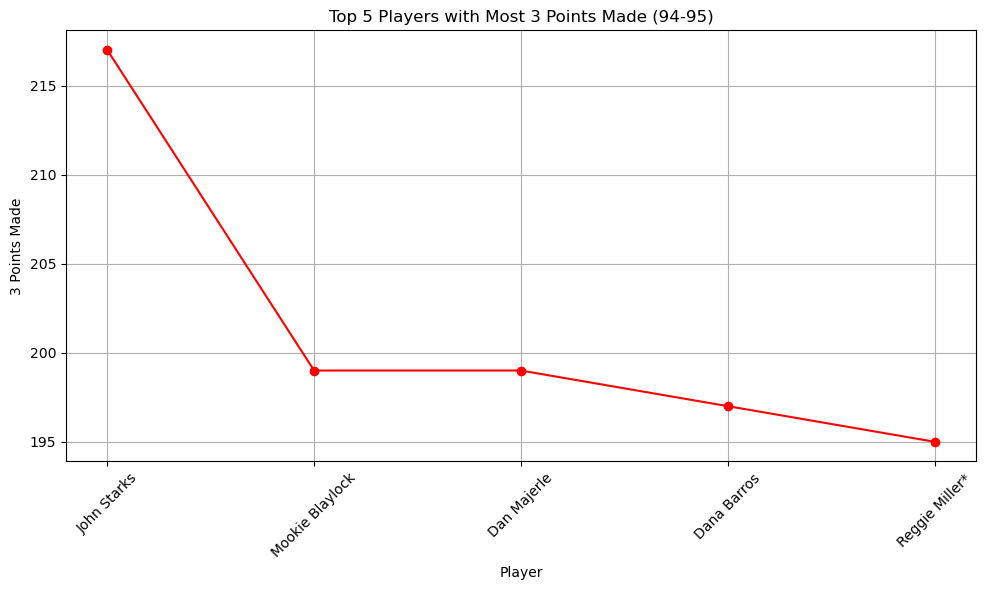

In [22]:
# Filter the data for the years 94-95
df_94_95 = df[(df['YEAR'] == '94-95')]

player_3P = df_94_95.groupby('Player')['3P'].sum().reset_index()

# Sort the players by the number of 3-pointers made
player_3P_sorted = player_3P.sort_values(by='3P', ascending=False).head(5)

# Plotting the line plot
plt.figure(figsize=(10, 6))
plt.plot(player_3P_sorted['Player'], player_3P_sorted['3P'], marker='o', linestyle='-', color='r')

# Adding labels and title
plt.title('Top 5 Players with Most 3 Points Made (94-95)')
plt.xlabel('Player')
plt.ylabel('3 Points Made')
plt.xticks(rotation=45)  # Rotate player names for better readability

plt.grid(True)
plt.tight_layout()

#### 3. What is the relationship between the player’s age and the number of points scored? The scatter plot should show the player's age on the x-axis, and the number of points scored on the y-axis.

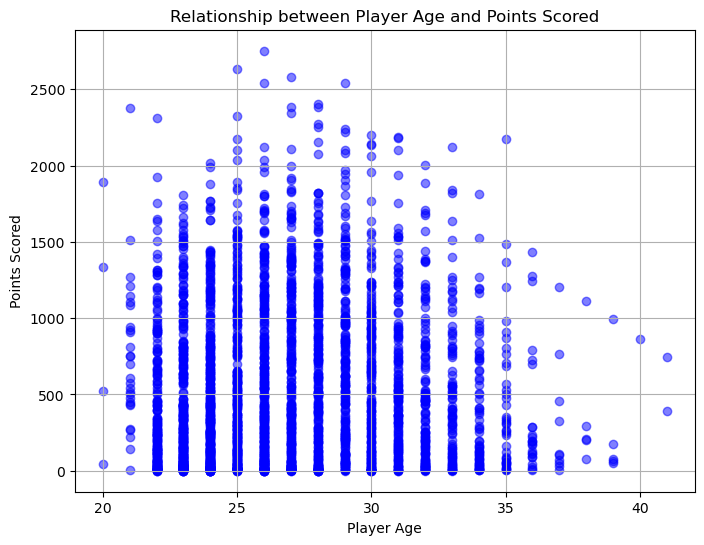

In [23]:
player_age = df['Age']
points_scored = df['PTS']

# Create scatter plot
plt.figure(figsize=(8, 6))  # Adjust size as needed
plt.scatter(player_age, points_scored, color='blue', alpha=0.5)  # alpha controls transparency
plt.title('Relationship between Player Age and Points Scored')
plt.xlabel('Player Age')
plt.ylabel('Points Scored')
plt.grid(True)  # Add grid
plt.show()

#### 4. Create a boxplot that show the number of points scored for each position in the year 90-91.

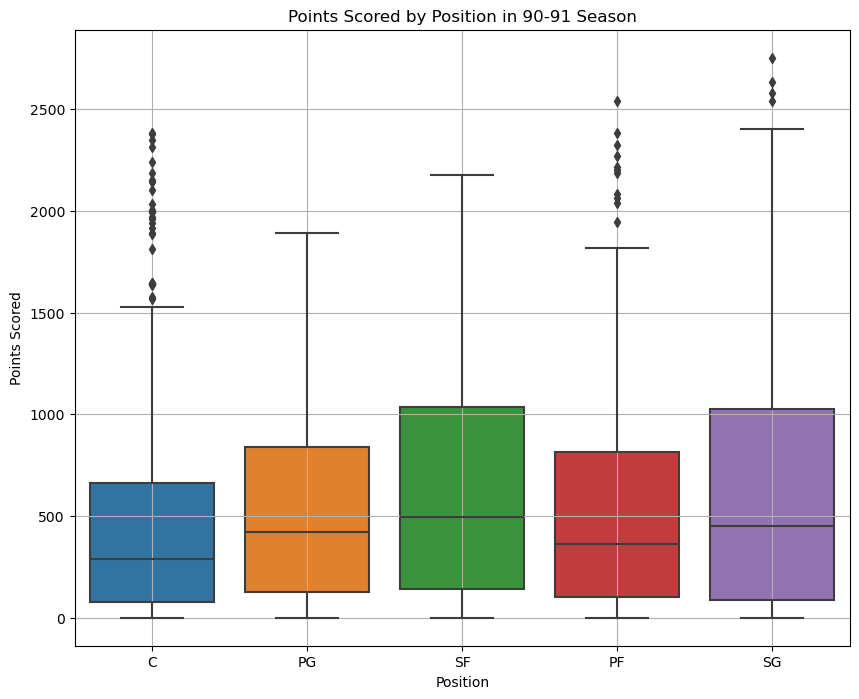

In [24]:
# Create a DataFrame with the data
data = {
    'Position':  df['Pos'],
    'Points Scored': df['PTS']
}

# Create a boxplot
plt.figure(figsize=(10, 8))  # Adjust size as needed
sns.boxplot(x='Position', y='Points Scored', data=data)
plt.title('Points Scored by Position in 90-91 Season')
plt.xlabel('Position')
plt.ylabel('Points Scored')
plt.grid(True)  # Add grid
plt.show()

#### 5. Create a bar chart that shows the total number of players by age in the year 90-91

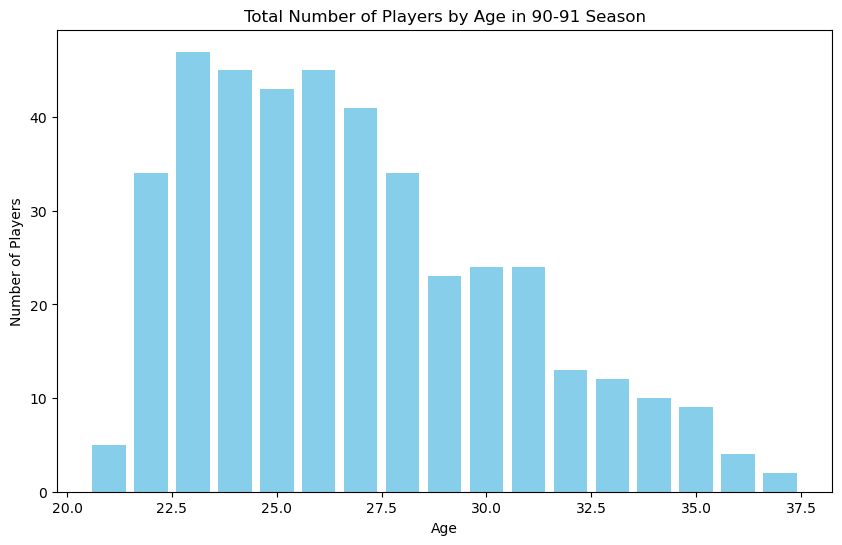

In [25]:
#Filter the data for the year 90-91.
df_90_91 = df[df['YEAR'] == '90-91']

#filtered data by age and count the number of players in each age group
age_counts = df_90_91['Age'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(age_counts.index, age_counts.values, color='skyblue')
plt.xlabel('Age')
plt.ylabel('Number of Players')
plt.title('Total Number of Players by Age in 90-91 Season')
plt.show()

#### 6. Create a bar chart that counts the number of players at each position in the year 90-91.

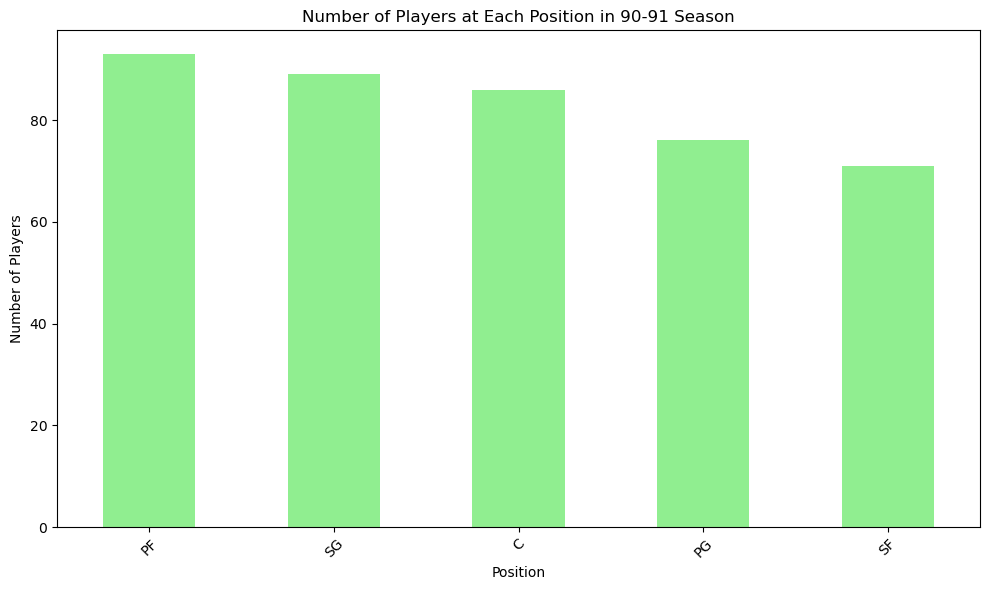

In [26]:
#Filter the data for the year 90-91.
df_90_91 = df[df['YEAR'] == '90-91']

# Count the number of players at each position.
position_counts = df_90_91['Pos'].value_counts()

plt.figure(figsize=(10, 6))
position_counts.plot(kind='bar', color='lightgreen')
plt.xlabel('Position')
plt.ylabel('Number of Players')
plt.title('Number of Players at Each Position in 90-91 Season')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 7. Who lead the NBA in Total Rebounds in the year 91-92?

In [27]:
top_rebounder_91_92 = df[df['YEAR'] == '91-92'].nlargest(1, 'TRB')['Player'].values[0]
print("Player who led NBA in Total Rebounds in 91-92:", top_rebounder_91_92)

Player who led NBA in Total Rebounds in 91-92: Dennis Rodman*


#### 8. Who had the highest assist average in the year 93-94? What was the assist average for that player?

In [28]:
highest_assist_avg_93_94 = df[df['YEAR'] == '93-94'].nlargest(1, 'AST')['Player'].values[0]
assist_avg = df[df['YEAR'] == '93-94'].nlargest(1, 'AST')['AST'].values[0]
print("Player with highest assist average in 93-94:", highest_assist_avg_93_94)
print("Assist average:", assist_avg)

Player with highest assist average in 93-94: John Stockton*
Assist average: 1031
